# Resistance mutations in aquatic plastisphere microbiomes

All script files are located in `sbatch_files/`. 

Steps:
1. Download the fastq data (specified in *download.txt*) using `download.sh` 
2. Run Pipeline 1, see TODO_URL_TO_IT for more details. TODO: Ok to link to it or just describe it?
3. Download the card database using `download_card.sh`
4. Build the database for MuMaMe using `mumame_build.sh`
5. Run MuMaMe using `split_mumame.sh`, it will be grouped according to *beginning_filenames.txt*, in order to speed up the operation.
6. The files *\*.table.txt* and *\*.per-mutation.txt* will be used below.

# Data analysis
## Import data

In [71]:
rm(list = ls())
# Load Libraries
library("tidyverse")

# List all relevant files
all_files_list <- list.files(path = "Mumame_results", pattern = "*.per-mutation.txt", full.names = TRUE) 
# See also pattern = "*.table.txt"
# per-mutation splits the Accession into one line per mutation, and uses the same hits for all. Easier with splitting below but result feels it could be wrong?

# Create the beginnings of the large dataframe
df_counts <- read_tsv(all_files_list[1], show_col_types = FALSE)

# Loop over all files, joining it to the larger dataframe. 
for (file in all_files_list[-1]) {
  df_counts <- read_tsv(file = file, show_col_types = FALSE) %>%
    full_join(df_counts, ., by = "Accession")
}
# Rename to not confuse with ARO accession later
df_counts <- df_counts %>%
  rename(Description = Accession)
dim(df_counts)

[1]  492 1573

## Import metadata

In [72]:
# Load in the metadata tables
snps <- read_tsv("card-data/snps.txt", show_col_types = FALSE)
cat("SNPS\n Dimensions of unmodified: "); cat(dim(snps))
snps <- snps %>%
  select(-citation) %>%
  unique.data.frame()
cat("\n Dimensions of filtered:   "); cat(dim(snps))

aro_index <- read_tsv("card-data/aro_index.tsv", show_col_types = FALSE)
cat("\n\nARO_INDEX\n Dimensions of filtered:   "); cat(dim(aro_index))
aro_index <- aro_index %>%
  # Rename it to match for later
  rename(Accession = `ARO Accession`) %>%
  mutate(Accession = as.double(str_remove(Accession, "ARO:"))) %>%
  select(Accession, `AMR Gene Family`, `Drug Class`, `Resistance Mechanism`) %>%
  unique.data.frame()
cat("\n Dimensions of filtered:   "); cat(dim(aro_index))

aro_categories <- read_tsv("card-data/aro_categories.tsv", show_col_types = FALSE)
aro_categories_index <- read_tsv("card-data/aro_categories_index.tsv", show_col_types = FALSE)

sample_metadata <- read_tsv("sample_metadata.tsv", show_col_types = FALSE)
sample_metadata <- sample_metadata %>% 
    select(run_accession, study_accession, Sampletype, Substrate, Latitude, Longitude)

SNPS
 Dimensions of unmodified: 3247 8
 Dimensions of filtered:   2711 7

ARO_INDEX
 Dimensions of filtered:   6444 12


 Dimensions of filtered:   6439 4

## To be removed?

In [73]:
# Some of the duplicates before filtered snps.txt:
#'N499T:Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones'
#'E501D:Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones'
#'S441Q:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'D142G:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid'
#'Q432K:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'D435A:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'H445P:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'S441L:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'Y334H:Mycobacterium tuberculosis embB mutant conferring resistance to ethambutol'
#'A504V:Mycobacterium tuberculosis gyrB mutant conferring resistance to fluoroquinolones'
#'R463L:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid'
#'S450F:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'H445N:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'I491F:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'
#'V170F:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin'

## Sanity checks
# Show one row which contain data for both samples
# For per-mutation.txt
#df_counts[which(df_counts["Accession"] == "A67T:Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid"), c(1:5, 39:63, 1100:1103)]
#df_counts[which(df_counts["Accession"] == "V90A:Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid"), c(1:5, 39:63, 1100:1103)]
# Below for table.txt
#df_counts[which(df_counts["Accession"] == "A67T+V90A:Staphylococcus aureus fusA with mutation conferring resistance to fusidic acid"), c(1:5, 39:63, 1100:1103)]

# Print the metadata tables
#print("snps")
#snps
#print("aro_index")
#aro_index
#print("aro_categories")
#aro_categories
#print("aro_categories_index")
#aro_categories_index

## Relative Abundances

In [74]:
# Get readcount before deleting that row
df_readcount <- df_counts[which(df_counts[, 1] == "TOTAL READS:"), ]
df_counts <- df_counts[-which(df_counts$Description == "TOTAL READS:"), ]

# Get relative abundances for each sample, separate for forward and reverse:
df_relative <- df_counts %>%
  mutate(across(ends_with('-Mut'), ~ . / (. + get(str_replace(cur_column(), "-Mut$", "-WT"))), .names = "{.col}_relative")) %>%
  rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_val-Mut")) %>%
  select(-ends_with(c("-Mut", "-WT"))) %>%
  rename_at(vars(ends_with('_relative')), ~ str_remove(., "\\_relative"))
#head(df_relative)
# Replace all NA:s with zeros?
#df_relative %>%
#  mutate_all(~replace(., is.na(.), 0)) %>%
#  select(-Accession)

# Identify Inf:s
#df_counts[which(df_relative$DRR528401_1_relative == Inf), c("Accession", "DRR528401_1_val-Mut", "DRR528401_1_val-WT", "DRR528402_1_val-Mut", "DRR528402_1_val-WT")]
#df_relative[which(df_relative$DRR528401_1_relative == Inf), c("Accession", "DRR528401_1_relative", "DRR528402_1_relative")]

## Transposing the dataframe

In [75]:
# Gives us a dataframe where row = sample and column = mutation
df_transposed <- df_relative %>%
    column_to_rownames(var = "Description") %>%
    rownames_to_column() %>%  
    pivot_longer(-rowname) %>% 
    pivot_wider(names_from=rowname, values_from=value) %>%
    rename(Sample = name)

# Replace all NA:s with zeros (copied from above), needed because '1 + NA = NA'
df_transposed <- df_transposed %>%
  mutate_all(~replace(., is.na(.), 0)) 

non_zero_count <- colSums(df_transposed != 0) # Count non-zero values per column
selected_cols <- names(non_zero_count[non_zero_count > 3]) # Get column names with more than 3 non-zero values
df_transposed_filtered <- df_transposed[, selected_cols] # Filter the table for selected columns
cat("\nDim unmodified: "); cat(dim(df_transposed))
cat("\nDim filtered:   "); cat(dim(df_transposed_filtered))


Dim unmodified: 786 492
Dim filtered:   786 212

## Create genes metadata dataframe

In [76]:
# 1. Mumame -> shortname
# 2. shortname -> snps.txt -> aro number
# 3. aro number -> aro_index.tsv -> categories

df_genes_metadata <- df_relative %>%
    # Extract and add mutation names (Note "Wildtype" in some)
    mutate(Mutations = str_split_i(Description, ":", i = 1),
           Name = str_split_i(Description, ":", i = 2)) %>%
    # Split further? Not needed if use per-mutation
        #df_counts$mutations %>%
        #    str_split("\\+")
    # Add real accession from snps to the dataframe
    left_join(., snps, by = c("Name", "Mutations")) %>%
    # Add the categories from aro_index 
    left_join(aro_index, by = "Accession")

#print("df_genes_metadata")
#head(df_genes_metadata)

#Detected an unexpected many-to-many relationship between `x` and `y`.
#ℹ Row 44 of `x` matches multiple rows in `y`.
#ℹ Row 2963 of `y` matches multiple rows in `x`.

## Create sample metadata dataframe

In [77]:
df_sample_metadata <- df_transposed_filtered %>%
    # Remove the read direction to get common sample name
    mutate(run_accession = str_remove(Sample, "_1|_2")) %>%
    # Add the metadata by the common sample name
    left_join(x = ., y = sample_metadata, by = join_by(run_accession))
#dim(df_transposed)
#length(df_sample_metadata$Sampletype)
#df_sample_metadata[which(is.na(df_sample_metadata$Sampletype)), ]

which(is.na(df_sample_metadata$Sampletype))
unique(df_sample_metadata$Sampletype)

integer(0)

[1] "Plastic"     "Water"       "Non-plastic"

## To be removed?

In [78]:

#select(snps, Name, Mutations) %>%
#    unique() %>%
#    inner_join(snps)
#print("TooLong")
#tooLongDF <- left_join(x = df_genes_metadata, y = snps, by = c("Name", "Mutations"), relationship = "one-to-one")
#dim(tooLongDF)
#duprows <- tooLongDF[duplicated(tooLongDF$Description)|duplicated(tooLongDF$Description, fromLast = TRUE), ]
#duprows$rowcount <- duprows %>%
#    select(ends_with(c("Mut", "WT"))) %>%
#    rowSums(na.rm = TRUE)
#duprows %>%
#    select(-ends_with(c("Mut", "WT")))

#print("S441Q:")
#duprows[which(duprows$Description == "S441Q:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin"),]
#print("Duplicate descriptions")
#tooLongDF$Description[duplicated(tooLongDF$Description)]
#head(df_genes_metadata)

#cat("\nUnique Descriptions metadata"); length(unique(df_genes_metadata$Description))
#cat("\nTotal Descriptions"); length(df_genes_metadata$Description)
#cat("\nUnique Descriptions toolong"); length(unique(tooLongDF$Description))
#cat("\nTotal Descriptions"); length(tooLongDF$Description)

#cat("\n Multiple with the same accession in df_genes_metadata"); df_genes_metadata[which(df_genes_metadata$Accession == 3003392),]
# Multiple matches of A381V in the snps dataframe
#cat("\nSNPS multiples:"); snps[which(snps$Mutations == "A381V"),]
# multiple mathces of G124S in the df_counts dataframe
#cat("\ndf_counts multiples:"); df_counts[which(df_counts$Mutations == "G124S"), ]

#cat("\nSNPS row 29:"); snps[29, ]
#cat("\ndf_genes_metadata row 8:"); df_genes_metadata[8, ]
#cat("\ndf_genes_metadata"); head(df_genes_metadata)

# Visualization

## Readcounts

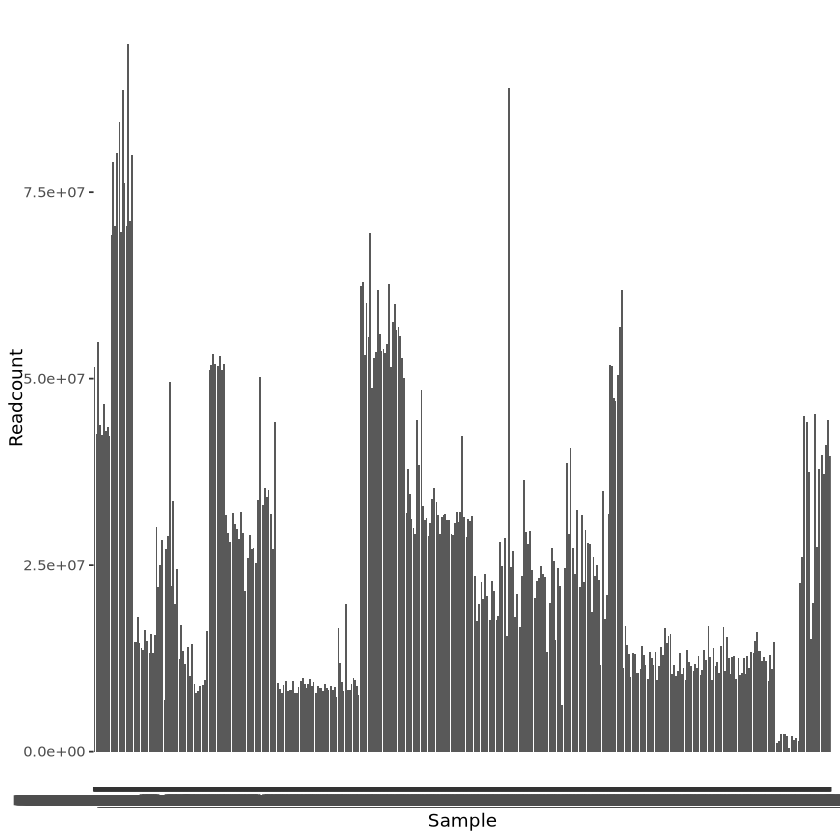

In [79]:
# Gives us a dataframe where row = sample and column = mutation
df_readcount_transposed <- df_readcount %>%
    column_to_rownames(var = "Description") %>%
    rownames_to_column() %>%  
    pivot_longer(-rowname) %>% 
    pivot_wider(names_from=rowname, values_from=value) %>%
    rename(Sample = name, Readcount = 'TOTAL READS:')

df_readcount_transposed %>%
    #filter(Readcount < 5000000) %>%
    ggplot(aes(Sample, Readcount))+
    geom_col()

In [80]:
head(df_sample_metadata)

Sample,A109T:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,A139V:Mycobacterium tuberculosis katG mutations conferring resistance to isoniazid,V287F:Mycobacterium tuberculosis embC mutant conferring resistance to ethambutol,G288V:Mycobacterium tuberculosis embC mutant conferring resistance to ethambutol,A375T:Escherichia coli EF-Tu mutants conferring resistance to Enacyloxin IIa,A381V:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin,A412V:Mycobacterium tuberculosis rpsA mutations conferring resistance to pyrazinamide,A451G:Mycobacterium tuberculosis rpoB with mutations conferring resistance to rifampicin,A67S:Escherichia coli gyrA conferring resistance to fluoroquinolones,⋯,F330S:Mycobacterium tuberculosis embB mutant conferring resistance to ethambutol,I491T:Mycobacterium tuberculosis rpoC mutations confer resistance to rifampicin,L525P:Helicobacter pylori rpoB mutation conferring resistance to rifampicin,Q527K:Helicobacter pylori rpoB mutation conferring resistance to rifampicin,run_accession,study_accession,Sampletype,Substrate,Latitude,Longitude
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
DRR528401_1,0,0.25000000,0.1666667,0.1666667,1,0.052980132,0.0,0,0.00000000,⋯,0,0,0,0,DRR528401,PRJDB17400,Plastic,Plastic,35.834,139.607
DRR528401_2,0,0.11111111,0.0000000,0.0000000,1,0.008264463,0.2,0,0.00000000,⋯,0,0,0,0,DRR528401,PRJDB17400,Plastic,Plastic,35.834,139.607
DRR528402_1,0,0.00000000,0.0000000,0.0000000,1,0.023255814,0.0,0,0.00000000,⋯,0,0,0,0,DRR528402,PRJDB17400,Plastic,Plastic,35.648,139.841
DRR528402_2,0,0.00000000,0.0000000,0.0000000,1,0.000000000,0.0,0,0.00000000,⋯,0,0,0,0,DRR528402,PRJDB17400,Plastic,Plastic,35.648,139.841
DRR528403_1,0,0.02173913,0.0000000,0.0000000,1,0.000000000,0.0,0,0.01408451,⋯,0,0,0,0,DRR528403,PRJDB17400,Plastic,Plastic,35.911,140.496
DRR528403_2,0,0.00000000,0.0000000,0.0000000,1,0.107142857,0.0,0,0.00000000,⋯,0,0,0,0,DRR528403,PRJDB17400,Plastic,Plastic,35.911,140.496


[1] "Plastic"     "Water"       "Non-plastic"

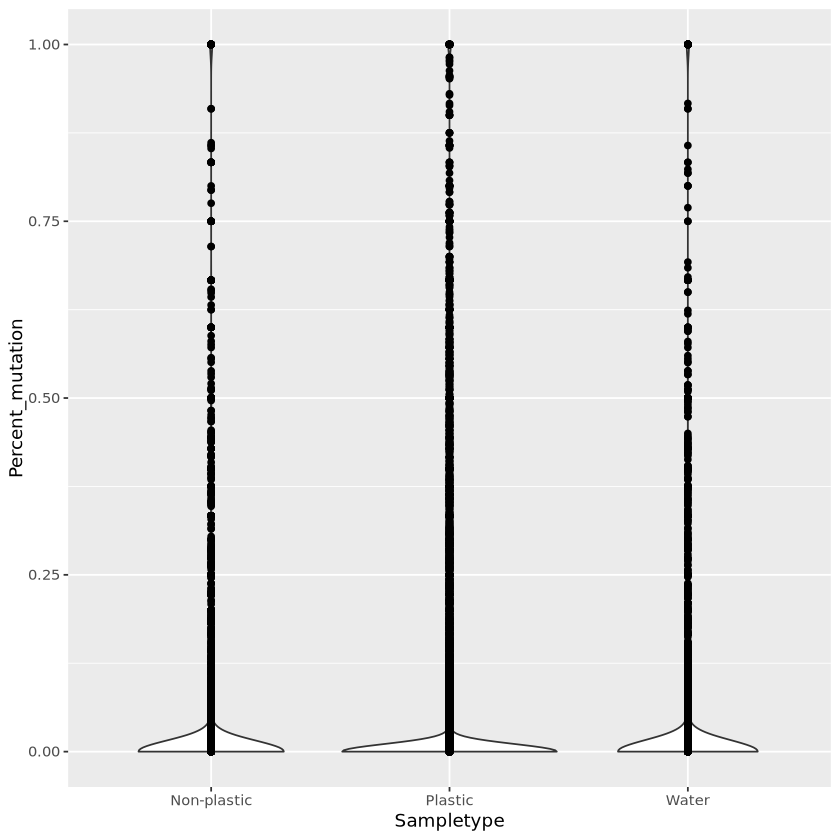

In [81]:
df_long <- df_sample_metadata %>%
    select(Sampletype, contains(":")) %>%
    pivot_longer(!Sampletype, names_to = "Description", values_to = "Percent_mutation")

unique(df_long$Sampletype)

df_long %>%
 ggplot(aes(Sampletype, Percent_mutation))+
     geom_violin()+
     geom_point()